In [1]:
Output = '/Users/alexis/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/CEMALB_DataAnalysisPM/Projects/P1016. THC Adducts/P1016.3. Analyses/P1016.3.2. Cluster Analysis'
cur_date = "092126"

library(readxl)
library(tidyverse)
library(reshape2)
library(factoextra)
library(gridExtra)
library(ggrepel)
library(pheatmap)

# reading in files
genes_df = data.frame(read_excel("Input/Normalized_THC_Genes_091826.xlsx")) #%>%
    #column_to_rownames(var = "ENSEMBL_ID")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [2]:
head(genes_df)

,ENSEMBL_ID,P1_Control,P2_Control,P3_Control,P1_D8THC,P2_D8THC,P3_D8THC,P1_D8THCq,P2_D8THCq,P3_D8THCq
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000000003,10.990138,10.896354,10.9276379,10.930041,10.945374,10.916148,11.089867,10.968764,11.211598
2,ENSG00000000419,10.671108,10.531594,10.6616560,10.691081,10.578911,10.815436,11.283165,10.709748,11.302640
3,ENSG00000000457,7.890700,7.964725,7.6763376,7.860145,7.982778,8.055386,7.342812,7.676713,8.250021
4,ENSG00000000460,9.729668,9.517500,9.6336101,9.693458,9.750993,9.816236,7.619355,9.240398,6.845747
5,ENSG00000000938,3.872863,2.615943,0.9029524,0.000000,4.733146,4.157098,5.730201,2.582646,0.000000
6,ENSG00000000971,3.490283,2.399225,3.2778192,2.410395,3.608611,3.540550,5.923764,4.582298,7.118193


This analysis will use PCA to explore if there are clusters of sample conditions that condensate, burn condition, and the time point. PCA will be run initially and the eigenvector values will be averaged within each sample condition to improve the visualization and elucidate any clusters that may arise.

The second part of this analysis will leverage hierarchical clustering to determine if specific biomarkers cluster. The gene expression analysis will be further stratified by time point (4 and 24hrs).
CHANGE!!
# Principal Component Analysis (PCA)

In [8]:
full_df = genes_df %>%
    pivot_longer(cols = 2:ncol(genes_df), names_to = "Sample_ID", values_to = "Value") %>%
    separate(Sample_ID, sep = "_", c("Experiment", "Exposure"), remove = TRUE) %>%
    # creating sample ids
    unite("Sample_ID", c("ENSEMBL_ID", "Exposure"), remove = FALSE) %>%
    #select(-c("Sample_No", "Experiment")) #%>%
    pivot_wider(names_from = "Experiment", values_from = "Value") %>%
    column_to_rownames(var = "Sample_ID")

head(full_df)

,ENSEMBL_ID,Exposure,P1,P2,P3
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
ENSG00000000003_Control,ENSG00000000003,Control,10.99014,10.89635,10.92764
ENSG00000000003_D8THC,ENSG00000000003,D8THC,10.93004,10.94537,10.91615
ENSG00000000003_D8THCq,ENSG00000000003,D8THCq,11.08987,10.96876,11.21160
ENSG00000000419_Control,ENSG00000000419,Control,10.67111,10.53159,10.66166
ENSG00000000419_D8THC,ENSG00000000419,D8THC,10.69108,10.57891,10.81544
ENSG00000000419_D8THCq,ENSG00000000419,D8THCq,11.28317,10.70975,11.30264


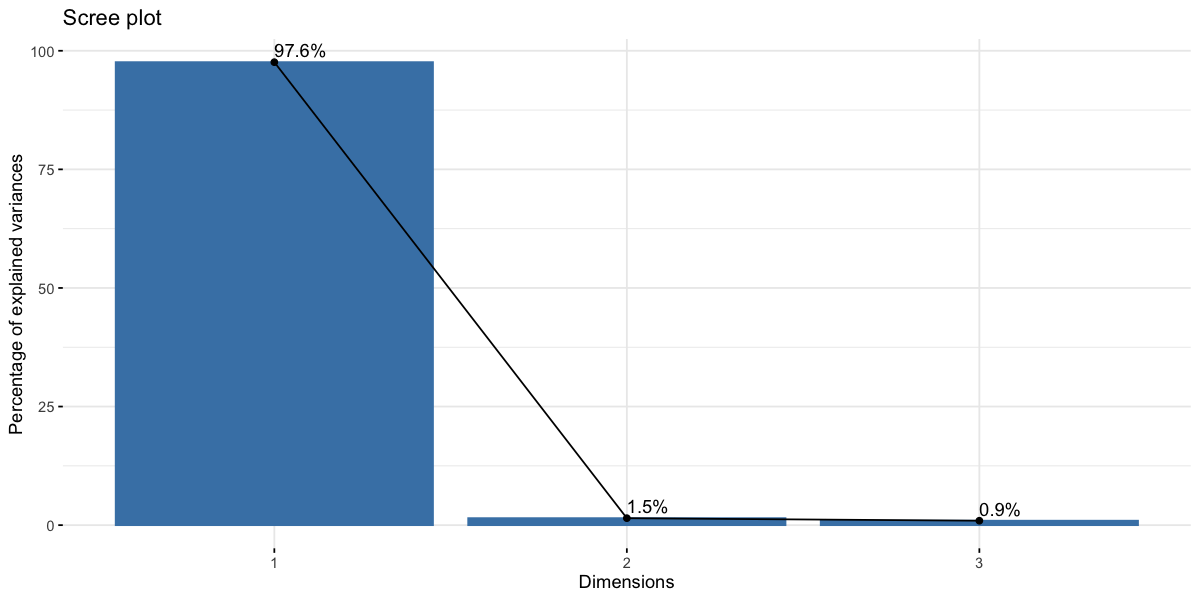

In [10]:
# running pca 
genes_pca = prcomp(full_df[,3:5], center = TRUE)

# looking a scree plot to see how much of the variance was captured in the first 2 eigenvectors
options(repr.plot.width = 10, repr.plot.height = 5) #changing size
fviz_eig(genes_pca, addlabels = TRUE)

The standard way to detect outliers in genetics is the criterion of being “more than 6 standard deviations away from the mean”. [source](https://privefl.github.io/blog/detecting-outlier-samples-in-pca/)

In [11]:
outlier_detection = function(pca_df){
    # """
    # Creating a scoring function for to detect PCA sample outliers. 
    # :param (input): PCA df (df)
    # :output: outlier names
    # """
    
    # getting scores
    scores = pca_df$x
    # identifying samples that are > 6 standard deviations away from the mean
    outlier_indices = apply(scores, 2, function(x) which( abs(x - mean(x)) > (6 * sd(x)) )) %>%
        Reduce(union, .)
    # getting sample names
    outliers = rownames(scores)[outlier_indices]
    
    return(outliers)
}

# calling fn
gene_outliers = outlier_detection(genes_pca)  

In [12]:
# getting length
length(gene_outliers)

[1] 14

There were 14 outliers which I'm going back to remove.

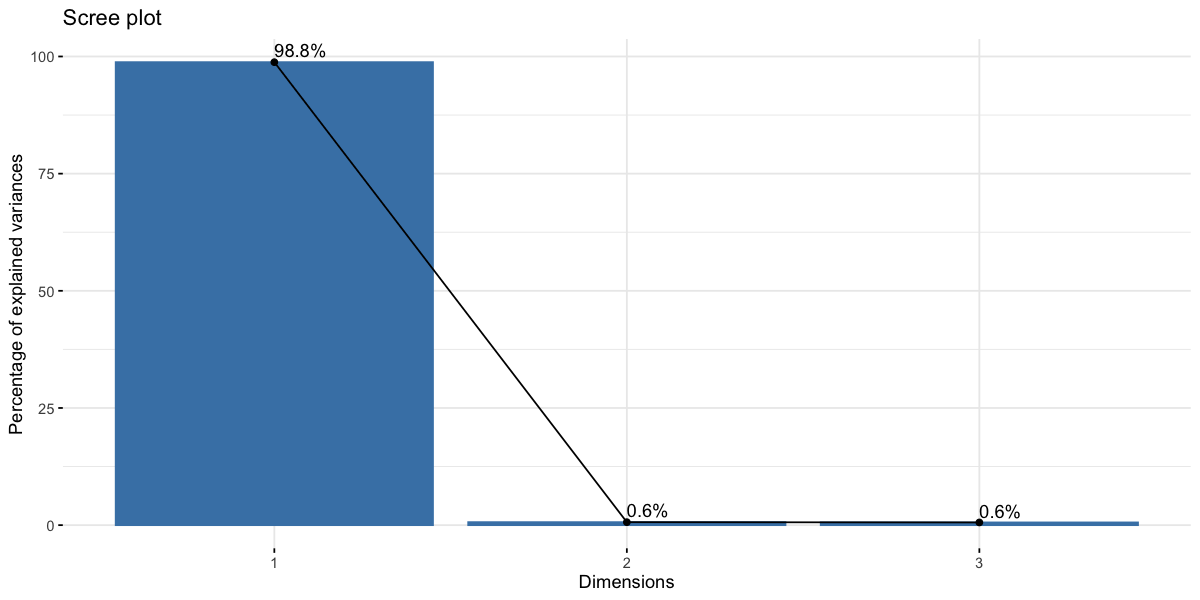

In [14]:
# going back to remove outliers
`%notin%` <- Negate(`%in%`)
no_outliers_genes_df = genes_df[row.names(genes_df) %notin% gene_outliers,]

# rerunning pca 
no_outliers_gene_pca = prcomp(no_outliers_genes_df[,3:5], center = TRUE)

# looking a scree plot to see how much of the variance was captured in first 2 eigenvectors
options(repr.plot.width = 10, repr.plot.height = 5) #changing size
fviz_eig(no_outliers_gene_pca, addlabels = TRUE)

It didn't much of a difference in terms of the amount of variance that was captured.

In [19]:
# creating 1 df with additional data
gene_pca_df = data.frame(genes_pca$x[,1:2]) %>%
               rownames_to_column(var = "Sample_ID") 

full_gene_df = inner_join(full_df[,1:2] %>% 
                                    rownames_to_column(var = "Sample_ID"), 
                                gene_pca_df) 

head(full_gene_df)

Joining with `by = join_by(Sample_ID)`


,Sample_ID,ENSEMBL_ID,Exposure,PC1,PC2
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,ENSG00000000003_Control,ENSG00000000003,Control,-10.083016,0.060989208
2,ENSG00000000003_D8THC,ENSG00000000003,D8THC,-10.070004,0.085915591
3,ENSG00000000003_D8THCq,ENSG00000000003,D8THCq,-10.346420,-0.099887647
4,ENSG00000000419_Control,ENSG00000000419,Control,-9.534688,-0.007529953
5,ENSG00000000419_D8THC,ENSG00000000419,D8THC,-9.662376,-0.097059249
6,ENSG00000000419_D8THCq,ENSG00000000419,D8THCq,-10.361010,-0.281412858


In [23]:
dim(full_gene_df)

[1] 86679     5

In [22]:
options(repr.plot.width=10, repr.plot.height=7) #changing size
FigureX = ggplot(data = full_gene_df, 
       aes(x = PC1, y = PC2, color = Exposure)) + 
  geom_point(size = 2) + 
  geom_text_repel(aes(label = Sample_ID), size = 5) + 

  theme_light() + 
  theme(axis.text.x = element_text(vjust = 0.5), #rotating x labels/ moving x labels slightly to the left
        axis.line = element_line(colour="black"), #making x and y axes black
        axis.text = element_text(size = 13), #changing size of x axis labels
        axis.title = element_text(face = "bold", size = rel(1.7)), #changes axis titles
        legend.position = 'none',
        strip.text.x = element_text(size = 18, face = "bold"), #changes size of facet x axis 
        strip.text.y = element_text(size = 18, face = "bold")) #+ #changes size of facet y axis 
  #labs(x = 'Dimension 1 (76.5%)', y = 'Dimension 2 (9.9%)') #+ #changing axis labels 

  # scale_color_manual(values = c('#cb181d','#fb6a4a', # cardboard flaming
  #                            "#b56800", "#f09900", # cardboard smoldering
  #                            "#4d4d4d", "#808080", # controls
  #                             '#0000c1','#7f52ff', # cardboard flaming
  #                            "#005200", "#3aa22b")) # cardboard smoldering  
FigureX